# Feature Selection HY 3 STAGE

In [61]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

current_dir = Path.cwd()
project_root = current_dir.parents[2]
path_data = project_root / 'DATA_PPMI/Results/MODEL_DATA/DATA_BL_V08.csv'
data = pd.read_csv(path_data,index_col=0)

def HY_classification(nhy):
    if nhy == 0:
        return 0  # Healthy
    elif nhy  in [1,2]:
        return 1  # Early Stage
    else:
        return 2  # Advanced Stage

data["STAGE"] = data["NHY"].apply(HY_classification)

V08_cols = ['ENRLLRRK2', 'ENRLGBA', 'COHORT_DEFINITION', 'SEX', 'RAWHITE', 'EDUCYRS', 'AGE_AT_VISIT', "NHY", "STAGE"]
data_V08 = data[V08_cols+['EVENT_ID']].copy()
data_V08 = data_V08.loc[data_V08["EVENT_ID"] == 'V08',:]  # last visit
data_V08.drop(columns=["EVENT_ID",'COHORT_DEFINITION',], inplace=True) 

other_cols = [col for col in data.columns if col not in V08_cols]
data_removed = data[V08_cols].copy()
data_stats = data[other_cols].copy()
data_stats = data_stats.loc[data_stats["EVENT_ID"].isin(['BL','V04','V06']),:]  # last visit
data_stats.drop(columns=["EVENT_ID"], inplace=True)

df_grouped = data_stats.groupby(level="PATNO")

df_mean = df_grouped.mean().add_suffix("_mean")
df_min  = df_grouped.min().add_suffix("_min")
df_max  = df_grouped.max().add_suffix("_max")
df_var  = df_grouped.var().add_suffix("_var")
df_std  = df_grouped.std().add_suffix("_std")

data_stats = pd.concat([df_mean, df_min, df_max, df_var, df_std], axis=1)


In [62]:
print("data_V08:", data_V08.shape)
data_V08.head()

data_V08: (909, 8)


,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,NHY,STAGE
PATNO,,,,,,,,
3003,0,0,0.0,1.0,16.0,59.7,2.0,1
3018,0,0,0.0,1.0,16.0,63.6,2.0,1
3020,0,0,0.0,1.0,15.0,77.0,3.0,2
3028,0,0,1.0,1.0,22.0,78.8,2.0,1
3051,0,0,1.0,1.0,18.0,74.7,2.0,1


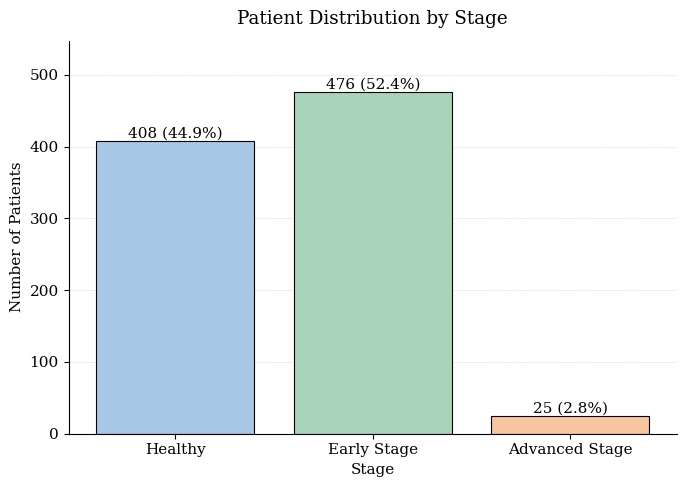

In [63]:
import matplotlib.pyplot as plt

# Conteo asegurando el orden 0-1-2
counts = data_V08['STAGE'].value_counts().reindex([0,1,2])

# Etiquetas de cada stage
stage_labels = {
    0: "Healthy",
    1: 'Early Stage',
    2: "Advanced Stage",
}

counts_df = counts.reset_index()
counts_df.columns = ['Stage', 'Count']
counts_df['Stage_label'] = counts_df['Stage'].map(stage_labels)

# Porcentajes
total = counts_df['Count'].sum()
counts_df['Pct'] = counts_df['Count'] / total * 100

# Colores pastel
color_map = {
    0: "#A7C7E7",  # azul pastel
    1: "#A8D5BA",  # verde pastel
    2: "#F7C59F",  # naranja pastel
}

colors = [color_map[i] for i in counts_df['Stage']]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    counts_df['Stage_label'],
    counts_df['Count'],
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Texto encima de las barras
for bar, count, pct in zip(bars, counts_df['Count'], counts_df['Pct']):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{count} ({pct:.1f}%)",
        ha='center',
        va='bottom'
    )

ax.set_title("Patient Distribution by Stage", pad=12)
ax.set_xlabel("Stage")
ax.set_ylabel("Number of Patients")

# Estilo limpio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)

ax.set_ylim(0, counts_df['Count'].max()*1.15)

plt.tight_layout()
plt.show()

In [64]:
print("data_stats:", data_stats.shape)
data_stats.head()

data_stats: (909, 925)


,MCAALTTM_mean,MCACUBE_mean,MCACLCKC_mean,MCACLCKN_mean,MCACLCKH_mean,MCALION_mean,MCARHINO_mean,MCACAMEL_mean,MCAFDS_mean,MCABDS_mean,...,NP3PTRMR_std,NP3PTRML_std,NP3KTRMR_std,NP3KTRML_std,NP3RTARU_std,NP3RTALU_std,NP3RTARL_std,NP3RTALL_std,NP3RTALJ_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
3003,1.000000,1.000000,1.0,1.0,0.666667,1.0,1.000000,1.0,1.0,1.000000,...,0.577350,0.577350,0.000000,0.57735,1.154701,0.000000,0.000000,0.0,0.0,0.577350
3018,1.000000,0.666667,1.0,1.0,0.333333,1.0,0.666667,1.0,1.0,0.666667,...,1.527525,1.154701,1.154701,0.57735,0.577350,0.577350,0.577350,0.0,0.0,1.527525
3020,0.666667,0.666667,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,1.000000,...,1.154701,0.000000,0.000000,0.00000,0.577350,1.154701,1.154701,0.0,0.0,1.154701
3028,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,0.666667,...,0.000000,0.000000,0.000000,0.57735,0.000000,1.527525,0.000000,0.0,0.0,1.527525
3051,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,1.000000,...,0.577350,0.000000,0.000000,0.00000,0.577350,0.000000,0.000000,0.0,0.0,0.577350


In [65]:
data_final = pd.merge(data_V08, data_stats, left_index=True, right_index=True)
print("data_final:", data_final.shape)
data_final.head()

data_final: (909, 933)


,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,NHY,STAGE,MCAALTTM_mean,MCACUBE_mean,...,NP3PTRMR_std,NP3PTRML_std,NP3KTRMR_std,NP3KTRML_std,NP3RTARU_std,NP3RTALU_std,NP3RTARL_std,NP3RTALL_std,NP3RTALJ_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
3003,0,0,0.0,1.0,16.0,59.7,2.0,1,1.000000,1.000000,...,0.577350,0.577350,0.000000,0.57735,1.154701,0.000000,0.000000,0.0,0.0,0.577350
3018,0,0,0.0,1.0,16.0,63.6,2.0,1,1.000000,0.666667,...,1.527525,1.154701,1.154701,0.57735,0.577350,0.577350,0.577350,0.0,0.0,1.527525
3020,0,0,0.0,1.0,15.0,77.0,3.0,2,0.666667,0.666667,...,1.154701,0.000000,0.000000,0.00000,0.577350,1.154701,1.154701,0.0,0.0,1.154701
3028,0,0,1.0,1.0,22.0,78.8,2.0,1,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.57735,0.000000,1.527525,0.000000,0.0,0.0,1.527525
3051,0,0,1.0,1.0,18.0,74.7,2.0,1,1.000000,1.000000,...,0.577350,0.000000,0.000000,0.00000,0.577350,0.000000,0.000000,0.0,0.0,0.577350


## DATA SPLIT

In [66]:
data_final.drop(columns=["NHY", "STAGE"]).to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv')
data_final["STAGE"].to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv')

In [67]:
train_data, test_data, train_target, test_target = train_test_split(
    data_final,
    data_final["STAGE"],
    test_size=0.2,
    random_state=42,
    stratify=data_final["STAGE"]
)

## Correlation Analysis

In [68]:
def correration_discard(train_data, threshold=0.9):
    list_vars_discard = []
    for type_corr in ['pearson', 'spearman']:
        # matriz de correlación
        corr_df = train_data.drop(columns=["NHY"]).corr(method=type_corr)

        # máscara para solo la parte inferior de la matriz
        mask = np.tril(np.ones(corr_df.shape), k=-1).astype(bool)

        # convertir a formato largo
        corr_long = (
            corr_df.where(mask)
            .stack()
            .reset_index()
            .rename(columns={"level_0": "V1", "level_1": "V2", 0: "CORR"})
        )

        # correlación con el target
        target_corr = corr_df["STAGE"]

        corr_long["V1target"] = corr_long["V1"].map(target_corr)
        corr_long["V2target"] = corr_long["V2"].map(target_corr)
        corr_long["WORST_VAR"] = np.where(
            abs(corr_long["V1target"]) <= abs(corr_long["V2target"]),
            corr_long["V1"],
            corr_long["V2"]
        )

        discard_corr_long = corr_long.loc[corr_long["CORR"].abs() > threshold]
        discard_vars = set(discard_corr_long["WORST_VAR"])
        print("Variables a descartar por alta correlación de ", type_corr, " con threshold ", threshold, ":", discard_vars,'\n', len(discard_vars))
        list_vars_discard.extend(list(discard_vars))
        
    print("Total variables a descartar por alta correlación con threshold ", threshold, ":", len(set(list_vars_discard)))
    return list(set(list_vars_discard))

In [ ]:
def correration_discard(train_data, threshold=0.9):
    list_vars_discard = []

    corr_df = train_data.drop(columns=["NHY"]).corr(method='spearman')

    # máscara para solo la parte inferior de la matriz
    mask = np.tril(np.ones(corr_df.shape), k=-1).astype(bool)

    # convertir a formato largo
    corr_long = (
            corr_df.where(mask)
            .stack()
            .reset_index()
            .rename(columns={"level_0": "V1", "level_1": "V2", 0: "CORR"})
        )

        # correlación con el target
    target_corr = corr_df["STAGE"]

    corr_long["V1target"] = corr_long["V1"].map(target_corr)
    corr_long["V2target"] = corr_long["V2"].map(target_corr)
    corr_long["WORST_VAR"] = np.where(
            abs(corr_long["V1target"]) <= abs(corr_long["V2target"]),
            corr_long["V1"],
            corr_long["V2"]
        )

    discard_corr_long = corr_long.loc[corr_long["CORR"].abs() > threshold]
    discard_vars = set(discard_corr_long["WORST_VAR"])
    print("Variables a descartar por alta correlación de spearman con threshold ", threshold, ":", discard_vars,'\n', len(discard_vars))
    list_vars_discard.extend(list(discard_vars))
        

    return list(set(list_vars_discard))

In [69]:
list_vars = correration_discard(train_data, threshold=0.90)
train_data_reduced = train_data.drop(columns=list_vars+["STAGE", "NHY"])
test_data_reduced = test_data.drop(columns=list_vars+["STAGE", "NHY"])

Variables a descartar por alta correlación de  pearson  con threshold  0.9 : {'STAIAD15_var', 'MCAABSTR_std', 'ESS5_var', 'NP1SLPD_std', 'GDSHOPLS_mean', 'NP1APAT_var', 'MCAYR_mean', 'STAIAD2_var', 'MCABDS_var', 'STAIAD36_std', 'MCARHINO_std', 'NP1APAT_std', 'NP3HMOVL_mean', 'MCASER7_var', 'MCAABSTR_var', 'MCAREC2_min', 'MCAFDS_min', 'GDSALIVE_min', 'NP3RTCON_var', 'NP1HALL_var', 'MCACLCKN_std', 'NP3RTARL_mean', 'STAIAD38_std', 'STAIAD17_var', 'HETRA_var', 'NP2SWAL_max', 'GDSWRTLS_max', 'MCADATE_std', 'MCAVIGIL_min', 'GDSEMPTY_max', 'NP3RTALJ_var', 'NP3LGAGL_var', 'GDSHOME_std', 'NP3RTARU_var', 'NP3BRADY_min', 'NP2SALV_max', 'SCAU8_max', 'SCAU1_var', 'MCAVFNUM_max', 'NP2RISE_mean', 'NP3RISNG_mean', 'MCAVFNUM_std', 'MCAVIGIL_mean', 'DRMOBJFL_var', 'MCALION_min', 'STAIAD23_mean', 'STAIAD19_var', 'MCAALTTM_mean', 'NP3PRSPL_mean', 'SLPINJUR_var', 'STAIAD3_std', 'STAIAD5_var', 'NP3RIGRU_max', 'MCADATE_min', 'MCACLCKC_std', 'STAIAD13_var', 'SCAU10_var', 'ESS6_max', 'NP1APAT_mean', 'NP1SLPN_v

In [70]:
train_data_reduced.head()

,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCACUBE_mean,MCACLCKC_mean,MCACLCKH_mean,MCACAMEL_mean,...,NP3PRSPL_std,NP3TTAPL_std,NP3LGAGR_std,NP3LGAGL_std,NP3GAIT_std,NP3POSTR_std,NP3BRADY_std,NP3PTRMR_std,NP3RTALU_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
53595,1,0,0.0,1.0,16.0,68.3,1.0,1.0,1.000000,1.0,...,1.154701,0.57735,0.577350,0.00000,0.00000,0.00000,0.57735,1.0,0.577350,2.309401
147368,0,0,1.0,1.0,19.0,70.7,1.0,1.0,1.000000,1.0,...,0.000000,1.00000,0.000000,0.57735,0.57735,0.57735,1.00000,0.0,0.000000,0.000000
3028,0,0,1.0,1.0,22.0,78.8,1.0,1.0,1.000000,1.0,...,0.000000,0.57735,0.577350,0.57735,0.57735,1.00000,0.57735,0.0,1.527525,1.527525
72283,0,1,1.0,1.0,20.0,62.6,1.0,1.0,1.000000,1.0,...,0.000000,0.57735,0.000000,0.57735,0.00000,0.00000,0.00000,0.0,0.000000,0.000000
3162,0,0,1.0,1.0,14.0,64.0,0.0,1.0,0.333333,1.0,...,0.577350,0.57735,1.154701,0.57735,0.57735,0.57735,0.57735,0.0,1.000000,0.577350


In [71]:
test_data_reduced.head()

,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCACUBE_mean,MCACLCKC_mean,MCACLCKH_mean,MCACAMEL_mean,...,NP3PRSPL_std,NP3TTAPL_std,NP3LGAGR_std,NP3LGAGL_std,NP3GAIT_std,NP3POSTR_std,NP3BRADY_std,NP3PTRMR_std,NP3RTALU_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
16644,0,0,1.0,1.0,16.0,67.2,0.333333,1.0,1.000000,1.0,...,0.00000,0.577350,0.00000,0.00000,0.00000,0.57735,0.57735,0.00000,0.0,0.000000
4005,0,0,1.0,1.0,13.0,75.6,1.000000,1.0,1.000000,1.0,...,0.57735,0.577350,0.57735,0.00000,0.57735,0.57735,0.00000,0.57735,0.0,1.000000
160231,0,0,0.0,1.0,16.0,72.3,1.000000,1.0,0.666667,1.0,...,1.00000,0.577350,0.00000,0.57735,0.00000,0.57735,0.57735,0.57735,0.0,1.732051
100511,0,0,0.0,1.0,13.0,66.5,1.000000,1.0,1.000000,1.0,...,0.57735,0.577350,0.00000,0.00000,0.00000,0.57735,0.00000,0.57735,0.0,0.000000
177768,0,0,0.0,1.0,17.0,67.2,1.000000,1.0,1.000000,1.0,...,0.00000,1.154701,0.57735,0.00000,0.00000,0.57735,0.57735,0.00000,0.0,0.000000


In [72]:

print("train_data_reduced shape:", train_data_reduced.shape)
print("test_data_reduced shape:", test_data_reduced.shape)
train_data_reduced.head()

train_data_reduced shape: (727, 414)
test_data_reduced shape: (182, 414)


,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCACUBE_mean,MCACLCKC_mean,MCACLCKH_mean,MCACAMEL_mean,...,NP3PRSPL_std,NP3TTAPL_std,NP3LGAGR_std,NP3LGAGL_std,NP3GAIT_std,NP3POSTR_std,NP3BRADY_std,NP3PTRMR_std,NP3RTALU_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
53595,1,0,0.0,1.0,16.0,68.3,1.0,1.0,1.000000,1.0,...,1.154701,0.57735,0.577350,0.00000,0.00000,0.00000,0.57735,1.0,0.577350,2.309401
147368,0,0,1.0,1.0,19.0,70.7,1.0,1.0,1.000000,1.0,...,0.000000,1.00000,0.000000,0.57735,0.57735,0.57735,1.00000,0.0,0.000000,0.000000
3028,0,0,1.0,1.0,22.0,78.8,1.0,1.0,1.000000,1.0,...,0.000000,0.57735,0.577350,0.57735,0.57735,1.00000,0.57735,0.0,1.527525,1.527525
72283,0,1,1.0,1.0,20.0,62.6,1.0,1.0,1.000000,1.0,...,0.000000,0.57735,0.000000,0.57735,0.00000,0.00000,0.00000,0.0,0.000000,0.000000
3162,0,0,1.0,1.0,14.0,64.0,0.0,1.0,0.333333,1.0,...,0.577350,0.57735,1.154701,0.57735,0.57735,0.57735,0.57735,0.0,1.000000,0.577350


In [73]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data_reduced)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=train_data_reduced.columns, index=train_data_reduced.index)

X_test_scaled = scaler.transform(test_data_reduced)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=test_data_reduced.columns, index=test_data_reduced.index)

print("X_train_scaled shape:", X_train_scaled.shape)
print("y_train shape:", train_target.shape)


X_train_scaled shape: (727, 414)
y_train shape: (727,)


In [74]:
X_train_scaled.head()

,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCACUBE_mean,MCACLCKC_mean,MCACLCKH_mean,MCACAMEL_mean,...,NP3PRSPL_std,NP3TTAPL_std,NP3LGAGR_std,NP3LGAGL_std,NP3GAIT_std,NP3POSTR_std,NP3BRADY_std,NP3PTRMR_std,NP3RTALU_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
53595,1.994856,-0.424494,-1.124632,0.214577,-0.198762,0.247171,0.733207,0.226666,0.645025,0.134934,...,2.232599,0.577763,1.066385,-0.704693,-0.744048,-0.856246,0.917309,2.402412,1.229188,4.062033
147368,-0.501289,-0.424494,0.889180,0.214577,0.710042,0.534107,0.733207,0.226666,0.645025,0.134934,...,-0.764838,1.706673,-0.639420,0.884148,1.114458,0.681280,2.187296,-0.683254,-0.481657,-0.673542
3028,-0.501289,-0.424494,0.889180,0.214577,1.618846,1.502515,0.733207,0.226666,0.645025,0.134934,...,-0.764838,0.577763,1.066385,0.884148,1.114458,1.806828,0.917309,-0.683254,4.044814,2.458747
72283,-0.501289,2.355748,0.889180,0.214577,1.012977,-0.434301,0.733207,0.226666,0.645025,0.134934,...,-0.764838,0.577763,-0.639420,0.884148,-0.744048,-0.856246,-0.817527,-0.683254,-0.481657,-0.673542
3162,-0.501289,-0.424494,0.889180,0.214577,-0.804631,-0.266922,-2.330249,0.226666,-1.903524,0.134934,...,0.733880,0.577763,2.772191,0.884148,1.114458,0.681280,0.917309,-0.683254,2.481614,0.510352


## Mutual Information

In [75]:
from sklearn.feature_selection import mutual_info_classif

X = X_train_scaled
y = train_target

mi = mutual_info_classif(X, y)
mi_series = pd.Series(mi, index=X_train_scaled.columns)
mi_series = mi_series.sort_values(ascending=False)

threshold = 0.025
selected_features = mi_series[mi_series > threshold]
selected_features.head()
list_selected_features = selected_features.index.tolist()

In [76]:
# duardar csv con las features seleccionadas
X_train_scaled[list_selected_features].to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/LATE_SELECTION/X_HY3_train.csv')
X_test_scaled[list_selected_features].to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/LATE_SELECTION/X_HY3_test.csv')
train_target.to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/LATE_SELECTION/y_HY3_train.csv')
test_target.to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/LATE_SELECTION/y_HY3_test.csv')

## Selection Evaluation

In [77]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

# Convierte a numpy denso (evita objetos raros/pickle)
X_train = np.asarray(X_train_scaled[list_selected_features], dtype=np.float32)
X_test  = np.asarray(X_test_scaled[list_selected_features],  dtype=np.float32)

y_train = np.asarray(train_target)
y_test  = np.asarray(test_target)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.base import clone
import numpy as np

def eval_model(model, name, X_train, y_train, X_test, y_test, n_splits=5):

    y_train = np.asarray(y_train).ravel()
    y_test  = np.asarray(y_test).ravel()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    n_classes = len(np.unique(y_train))

    oof_proba  = np.zeros((X_train.shape[0], n_classes))
    test_proba = np.zeros((X_test.shape[0], n_classes))

    print(f"\n{name}")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)

        # OOF probabilities
        proba_val = m.predict_proba(X_val)
        oof_proba[val_idx] = proba_val

        # Test probabilities averaged across folds
        test_proba += m.predict_proba(X_test) / n_splits

        fold_auc = roc_auc_score(y_val, proba_val, multi_class="ovr")
        print(f"Fold {fold}: AUC={fold_auc:.4f}")

    print("------")

    train_auc = roc_auc_score(y_train, oof_proba, multi_class="ovr")
    test_auc  = roc_auc_score(y_test,  test_proba, multi_class="ovr")

    print(f"OOF Train AUC: {train_auc:.4f}")
    print(f"Test CV  AUC: {test_auc:.4f}")

    return oof_proba, test_proba

# RF (puede ir con n_jobs>1, pero si te da el mismo problema ponlo en 1)
rf = RandomForestClassifier(
    n_estimators=600,
    random_state=42
)
oof_rf, test_rf = eval_model(rf, "RandomForest", X_train, y_train, X_test, y_test)

lr = LogisticRegression(
    solver="lbfgs",
    max_iter=5000,
    random_state=42
)
oof_lr, test_lr = eval_model(lr, "LogisticRegression", X_train, y_train, X_test, y_test)

# SVM con probas
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)
oof_svm, test_svm = eval_model(svm, "SVC_RBF", X_train, y_train, X_test, y_test)

xgb = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="mlogloss",
    )

oof_xgb, test_xgb = eval_model(xgb, "XGBoost", X_train, y_train, X_test, y_test)


RandomForest
Fold 1: AUC=0.9601
Fold 2: AUC=0.9704
Fold 3: AUC=0.9441
Fold 4: AUC=0.9521
Fold 5: AUC=0.9407
------
OOF Train AUC: 0.9530
Test CV  AUC: 0.9295

LogisticRegression
Fold 1: AUC=0.8956
Fold 2: AUC=0.9497
Fold 3: AUC=0.8887
Fold 4: AUC=0.9495
Fold 5: AUC=0.8305
------
OOF Train AUC: 0.9031
Test CV  AUC: 0.9080

SVC_RBF
Fold 1: AUC=0.9608
Fold 2: AUC=0.9687
Fold 3: AUC=0.9207
Fold 4: AUC=0.9526
Fold 5: AUC=0.9292
------
OOF Train AUC: 0.9423
Test CV  AUC: 0.9224

XGBoost
Fold 1: AUC=0.9155
Fold 2: AUC=0.9654
Fold 3: AUC=0.9173
Fold 4: AUC=0.9563
Fold 5: AUC=0.8927
------
OOF Train AUC: 0.9305
Test CV  AUC: 0.8992


# Feature Selection HY 4 STAGE

In [78]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

current_dir = Path.cwd()
project_root = current_dir.parents[2]
path_data = project_root / 'DATA_PPMI/Results/MODEL_DATA/DATA_BL_V08.csv'
data = pd.read_csv(path_data,index_col=0)

def HY_classification(nhy):
    if nhy == 0:
        return 0  # Healthy
    elif nhy  == 1:
        return 1  # Early Stage
    elif nhy == 2:
        return 2  # Mid Stage
    else:
        return 3  # Advanced Stage

data["STAGE"] = data["NHY"].apply(HY_classification)

V08_cols = ['ENRLLRRK2', 'ENRLGBA', 'COHORT_DEFINITION', 'SEX', 'RAWHITE', 'EDUCYRS', 'AGE_AT_VISIT', "NHY", "STAGE"]
data_V08 = data[V08_cols+['EVENT_ID']].copy()
data_V08 = data_V08.loc[data_V08["EVENT_ID"] == 'V08',:]  # last visit
data_V08.drop(columns=["EVENT_ID",'COHORT_DEFINITION',], inplace=True) 

other_cols = [col for col in data.columns if col not in V08_cols]
data_removed = data[V08_cols].copy()
data_stats = data[other_cols].copy()
data_stats = data_stats.loc[data_stats["EVENT_ID"].isin(['BL','V04','V06']),:]  # last visit
data_stats.drop(columns=["EVENT_ID"], inplace=True)

df_grouped = data_stats.groupby(level="PATNO")

df_mean = df_grouped.mean().add_suffix("_mean")
df_min  = df_grouped.min().add_suffix("_min")
df_max  = df_grouped.max().add_suffix("_max")
df_var  = df_grouped.var().add_suffix("_var")
df_std  = df_grouped.std().add_suffix("_std")

data_stats = pd.concat([df_mean, df_min, df_max, df_var, df_std], axis=1)


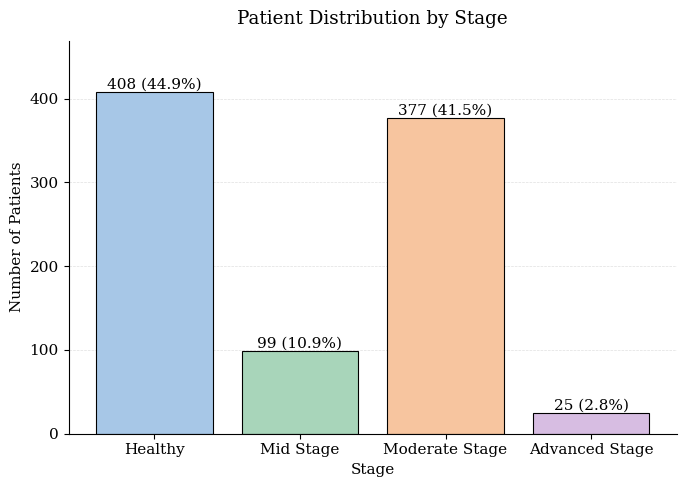

In [79]:
import matplotlib.pyplot as plt

# Conteo asegurando el orden 0-1-2-3
counts = data_V08['STAGE'].value_counts().reindex([0,1,2,3], fill_value=0)

# Etiquetas de cada stage
stage_labels = {
    0: "Healthy",
    1: 'Mid Stage',
    2: "Moderate Stage",
    3: "Advanced Stage"
}

counts_df = counts.reset_index()
counts_df.columns = ['Stage', 'Count']
counts_df['Stage_label'] = counts_df['Stage'].map(stage_labels)

# Porcentajes
total = counts_df['Count'].sum()
counts_df['Pct'] = counts_df['Count'] / total * 100

# Colores pastel
color_map = {
    0: "#A7C7E7",  # azul pastel
    1: "#A8D5BA",  # verde pastel
    2: "#F7C59F",  # naranja pastel
    3: "#D7BDE2"   # morado pastel
}

colors = [color_map[i] for i in counts_df['Stage']]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    counts_df['Stage_label'],
    counts_df['Count'],
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Texto encima de las barras
for bar, count, pct in zip(bars, counts_df['Count'], counts_df['Pct']):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{count} ({pct:.1f}%)",
        ha='center',
        va='bottom'
    )

ax.set_title("Patient Distribution by Stage", pad=12)
ax.set_xlabel("Stage")
ax.set_ylabel("Number of Patients")

# Estilo limpio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)

ax.set_ylim(0, counts_df['Count'].max()*1.15)

plt.tight_layout()
plt.show()

In [80]:
print("data_stats:", data_stats.shape)
data_stats.head()

data_stats: (909, 925)


,MCAALTTM_mean,MCACUBE_mean,MCACLCKC_mean,MCACLCKN_mean,MCACLCKH_mean,MCALION_mean,MCARHINO_mean,MCACAMEL_mean,MCAFDS_mean,MCABDS_mean,...,NP3PTRMR_std,NP3PTRML_std,NP3KTRMR_std,NP3KTRML_std,NP3RTARU_std,NP3RTALU_std,NP3RTARL_std,NP3RTALL_std,NP3RTALJ_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
3003,1.000000,1.000000,1.0,1.0,0.666667,1.0,1.000000,1.0,1.0,1.000000,...,0.577350,0.577350,0.000000,0.57735,1.154701,0.000000,0.000000,0.0,0.0,0.577350
3018,1.000000,0.666667,1.0,1.0,0.333333,1.0,0.666667,1.0,1.0,0.666667,...,1.527525,1.154701,1.154701,0.57735,0.577350,0.577350,0.577350,0.0,0.0,1.527525
3020,0.666667,0.666667,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,1.000000,...,1.154701,0.000000,0.000000,0.00000,0.577350,1.154701,1.154701,0.0,0.0,1.154701
3028,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,0.666667,...,0.000000,0.000000,0.000000,0.57735,0.000000,1.527525,0.000000,0.0,0.0,1.527525
3051,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,1.000000,...,0.577350,0.000000,0.000000,0.00000,0.577350,0.000000,0.000000,0.0,0.0,0.577350


In [81]:
data_final = pd.merge(data_V08, data_stats, left_index=True, right_index=True)
print("data_final:", data_final.shape)
data_final.head()

data_final: (909, 933)


,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,NHY,STAGE,MCAALTTM_mean,MCACUBE_mean,...,NP3PTRMR_std,NP3PTRML_std,NP3KTRMR_std,NP3KTRML_std,NP3RTARU_std,NP3RTALU_std,NP3RTARL_std,NP3RTALL_std,NP3RTALJ_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
3003,0,0,0.0,1.0,16.0,59.7,2.0,2,1.000000,1.000000,...,0.577350,0.577350,0.000000,0.57735,1.154701,0.000000,0.000000,0.0,0.0,0.577350
3018,0,0,0.0,1.0,16.0,63.6,2.0,2,1.000000,0.666667,...,1.527525,1.154701,1.154701,0.57735,0.577350,0.577350,0.577350,0.0,0.0,1.527525
3020,0,0,0.0,1.0,15.0,77.0,3.0,3,0.666667,0.666667,...,1.154701,0.000000,0.000000,0.00000,0.577350,1.154701,1.154701,0.0,0.0,1.154701
3028,0,0,1.0,1.0,22.0,78.8,2.0,2,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.57735,0.000000,1.527525,0.000000,0.0,0.0,1.527525
3051,0,0,1.0,1.0,18.0,74.7,2.0,2,1.000000,1.000000,...,0.577350,0.000000,0.000000,0.00000,0.577350,0.000000,0.000000,0.0,0.0,0.577350


## DATA SPLIT

In [82]:
data_final.drop(columns=["NHY", "STAGE"]).to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv')
data_final["STAGE"].to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv')

In [83]:
train_data, test_data, train_target, test_target = train_test_split(
    data_final,
    data_final["STAGE"],
    test_size=0.2,
    random_state=42,
    stratify=data_final["STAGE"]
)

## Correlation Analysis

In [84]:
list_vars = correration_discard(train_data, threshold=0.90)
train_data_reduced = train_data.drop(columns=list_vars+["STAGE", "NHY"])
test_data_reduced = test_data.drop(columns=list_vars+["STAGE", "NHY"])

Variables a descartar por alta correlación de  pearson  con threshold  0.9 : {'GDSENRGY_std', 'STAIAD15_var', 'NP3KTRML_max', 'MCAABSTR_std', 'ESS5_var', 'NP1SLPD_std', 'GDSHOPLS_mean', 'NP1APAT_var', 'MCAABSTR_min', 'MCAYR_mean', 'STAIAD2_var', 'MCARHINO_std', 'NP1APAT_std', 'NP3HMOVL_mean', 'GDSWRTLS_var', 'MCAABSTR_var', 'MCAREC2_min', 'MCAFDS_min', 'NP3RTCON_var', 'NP1HALL_var', 'MCACLCKN_std', 'NP3RTARL_mean', 'STAIAD38_std', 'NP2SWAL_max', 'GDSWRTLS_max', 'MCADATE_std', 'MCAVIGIL_min', 'GDSEMPTY_max', 'GDSAFRAD_var', 'NP3RTALJ_var', 'STAIAD24_mean', 'NP3LGAGL_var', 'GDSHOME_std', 'NP3RTARU_var', 'NP3BRADY_min', 'NP2SALV_max', 'SCAU1_var', 'STAIAD31_mean', 'GDSWRTLS_mean', 'MCAVFNUM_max', 'NP3RISNG_mean', 'MCAVFNUM_std', 'NP3TTAPR_var', 'DRMOBJFL_var', 'NP2RISE_max', 'STAIAD23_mean', 'STAIAD19_var', 'SCAU2_max', 'MCAALTTM_mean', 'NP3PRSPL_mean', 'STAIAD3_std', 'STAIAD5_var', 'SLPDSTRB_var', 'NP3RIGRU_max', 'MCACLCKC_std', 'STAIAD13_var', 'SCAU10_var', 'ESS6_max', 'NP1APAT_mean', '

In [85]:

print("train_data_reduced shape:", train_data_reduced.shape)
print("test_data_reduced shape:", test_data_reduced.shape)

train_data_reduced shape: (727, 425)
test_data_reduced shape: (182, 425)


In [86]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data_reduced)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=train_data_reduced.columns, index=train_data_reduced.index)

X_test_scaled = scaler.transform(test_data_reduced)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=test_data_reduced.columns, index=test_data_reduced.index)

print("X_train_scaled shape:", X_train_scaled.shape)
print("y_train shape:", train_target.shape)


X_train_scaled shape: (727, 425)
y_train shape: (727,)


## Mutual Information

In [87]:
from sklearn.feature_selection import mutual_info_classif

X = X_train_scaled
y = train_target

mi = mutual_info_classif(X, y)
mi_series = pd.Series(mi, index=X_train_scaled.columns)
mi_series = mi_series.sort_values(ascending=False)

threshold = 0.025
selected_features = mi_series[mi_series > threshold]
list_selected_features = selected_features.index.tolist()
selected_features.head()

NP3FACXP_mean    0.343028
NP3RTCON_max     0.326438
NP2TRMR_mean     0.310717
MSEADLG_mean     0.277121
NP3FTAPL_mean    0.257775
dtype: float64

In [88]:
# duardar csv con las features seleccionadas
X_train_scaled[list_selected_features].to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/LATE_SELECTION/X_HY4_train.csv')
X_test_scaled[list_selected_features].to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/LATE_SELECTION/X_HY4_test.csv')
train_target.to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/LATE_SELECTION/y_HY4_train.csv')
test_target.to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/LATE_SELECTION/y_HY4_test.csv')

## Selection Evaluation

In [89]:
# Convierte a numpy denso (evita objetos raros/pickle)
X_train = np.asarray(X_train_scaled[list_selected_features], dtype=np.float32)
X_test  = np.asarray(X_test_scaled[list_selected_features],  dtype=np.float32)

y_train = np.asarray(train_target)
y_test  = np.asarray(test_target)


# RF (puede ir con n_jobs>1, pero si te da el mismo problema ponlo en 1)
rf = RandomForestClassifier(
    n_estimators=600,
    random_state=42
)
oof_rf, test_rf = eval_model(rf, "RandomForest", X_train, y_train, X_test, y_test)

lr = LogisticRegression(
    solver="lbfgs",
    max_iter=5000,
    random_state=42
)
oof_lr, test_lr = eval_model(lr, "LogisticRegression", X_train, y_train, X_test, y_test)

# SVM con probas
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)
oof_svm, test_svm = eval_model(svm, "SVC_RBF", X_train, y_train, X_test, y_test)

xgb = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="mlogloss",
    )

oof_xgb, test_xgb = eval_model(xgb, "XGBoost", X_train, y_train, X_test, y_test)


RandomForest
Fold 1: AUC=0.9168
Fold 2: AUC=0.8895
Fold 3: AUC=0.9062
Fold 4: AUC=0.8956
Fold 5: AUC=0.9029
------
OOF Train AUC: 0.8991
Test CV  AUC: 0.8933

LogisticRegression
Fold 1: AUC=0.8286
Fold 2: AUC=0.8460
Fold 3: AUC=0.8194
Fold 4: AUC=0.8006
Fold 5: AUC=0.8458
------
OOF Train AUC: 0.8284
Test CV  AUC: 0.8389

SVC_RBF
Fold 1: AUC=0.9025
Fold 2: AUC=0.8754
Fold 3: AUC=0.8965
Fold 4: AUC=0.8888
Fold 5: AUC=0.8886
------
OOF Train AUC: 0.8873
Test CV  AUC: 0.8843

XGBoost
Fold 1: AUC=0.8898
Fold 2: AUC=0.8482
Fold 3: AUC=0.8651
Fold 4: AUC=0.8695
Fold 5: AUC=0.8635
------
OOF Train AUC: 0.8670
Test CV  AUC: 0.8834


# Feature Selection MCID

In [90]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

current_dir = Path.cwd()
project_root = current_dir.parents[2]
path_data = project_root / 'DATA_PPMI/Results/MODEL_DATA/DATA_BL_V08.csv'
data = pd.read_csv(path_data,index_col=0)

updrs3_cols=['NP3SPCH','NP3FACXP','NP3RIGN','NP3RIGRU','NP3RIGLU','NP3RIGRL','NP3RIGLL','NP3FTAPR','NP3FTAPL','NP3HMOVR','NP3HMOVL','NP3PRSPR','NP3PRSPL','NP3TTAPR','NP3TTAPL','NP3LGAGR','NP3LGAGL','NP3RISNG','NP3GAIT','NP3FRZGT','NP3PSTBL','NP3POSTR','NP3BRADY','NP3PTRMR','NP3PTRML','NP3KTRMR','NP3KTRML','NP3RTARU','NP3RTALU','NP3RTARL','NP3RTALL','NP3RTALJ','NP3RTCON']

V08_cols = ['ENRLLRRK2', 'ENRLGBA', 'COHORT_DEFINITION', 'SEX', 'RAWHITE', 'EDUCYRS', 'AGE_AT_VISIT']
data_V08 = data[V08_cols+['EVENT_ID']+updrs3_cols].copy()
data_V08['UPDRS3_TOTAL_V08'] = data_V08[updrs3_cols].sum(axis=1)
data_V08.drop(columns=updrs3_cols, inplace=True)
data_V08 = data_V08.loc[data_V08["EVENT_ID"] == 'V08',:]  # last visit

data_V06 = data[V08_cols+['EVENT_ID']+updrs3_cols].copy()
data_V06['UPDRS3_TOTAL_V06'] = data_V06[updrs3_cols].sum(axis=1)
data_V06.drop(columns=updrs3_cols, inplace=True)
data_V06 = data_V06.loc[data_V06["EVENT_ID"] == 'V06',:]  # actual visit

print("data_V08:", data_V08.shape)
print("data_V06:", data_V06.shape)

data_V08 = data_V08.merge(
    data_V06[['UPDRS3_TOTAL_V06']],
    left_index=True,
    right_index=True,
    how='inner'
)

print("data_V08 after merge:", data_V08.shape)
data_V08['Delta_UPDRS3'] = data_V08['UPDRS3_TOTAL_V08'] - data_V08['UPDRS3_TOTAL_V06']

def classification_mcid(x):
    if x <= -3:
        return 0  # Clinically meaningful improvement
    elif x >= 4:
        return 2   # Clinically meaningful worsening
    else:
        return 1   # Stable / no clinically meaningful change

data_V08['MCID_CLASS'] = data_V08['Delta_UPDRS3'].apply(classification_mcid)
data_V08.drop(columns=["EVENT_ID",'COHORT_DEFINITION','UPDRS3_TOTAL_V06','UPDRS3_TOTAL_V08', 'Delta_UPDRS3'], inplace=True)

data_V08.head()



data_V08: (909, 9)
data_V06: (909, 9)
data_V08 after merge: (909, 10)


,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCID_CLASS
PATNO,,,,,,,
3003,0,0,0.0,1.0,16.0,59.7,1
3018,0,0,0.0,1.0,16.0,63.6,1
3020,0,0,0.0,1.0,15.0,77.0,2
3028,0,0,1.0,1.0,22.0,78.8,0
3051,0,0,1.0,1.0,18.0,74.7,1


In [91]:
other_cols = [col for col in data.columns if col not in V08_cols]
data_removed = data[V08_cols].copy()
data_stats = data[other_cols].copy()
data_stats = data_stats.loc[data_stats["EVENT_ID"].isin(['BL','V04','V06']),:]  # last visit
data_stats.drop(columns=["EVENT_ID"], inplace=True)

df_grouped = data_stats.groupby(level="PATNO")

df_mean = df_grouped.mean().add_suffix("_mean")
df_min  = df_grouped.min().add_suffix("_min")
df_max  = df_grouped.max().add_suffix("_max")
df_var  = df_grouped.var().add_suffix("_var")
df_std  = df_grouped.std().add_suffix("_std")

data_stats = pd.concat([df_mean, df_min, df_max, df_var, df_std], axis=1)
data_stats.head()

,MCAALTTM_mean,MCACUBE_mean,MCACLCKC_mean,MCACLCKN_mean,MCACLCKH_mean,MCALION_mean,MCARHINO_mean,MCACAMEL_mean,MCAFDS_mean,MCABDS_mean,...,NP3PTRML_std,NP3KTRMR_std,NP3KTRML_std,NP3RTARU_std,NP3RTALU_std,NP3RTARL_std,NP3RTALL_std,NP3RTALJ_std,NP3RTCON_std,NHY_std
PATNO,,,,,,,,,,,,,,,,,,,,,
3003,1.000000,1.000000,1.0,1.0,0.666667,1.0,1.000000,1.0,1.0,1.000000,...,0.577350,0.000000,0.57735,1.154701,0.000000,0.000000,0.0,0.0,0.577350,0.00000
3018,1.000000,0.666667,1.0,1.0,0.333333,1.0,0.666667,1.0,1.0,0.666667,...,1.154701,1.154701,0.57735,0.577350,0.577350,0.577350,0.0,0.0,1.527525,0.00000
3020,0.666667,0.666667,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,1.000000,...,0.000000,0.000000,0.00000,0.577350,1.154701,1.154701,0.0,0.0,1.154701,0.57735
3028,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,0.666667,...,0.000000,0.000000,0.57735,0.000000,1.527525,0.000000,0.0,0.0,1.527525,0.00000
3051,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,1.000000,...,0.000000,0.000000,0.00000,0.577350,0.000000,0.000000,0.0,0.0,0.577350,0.00000


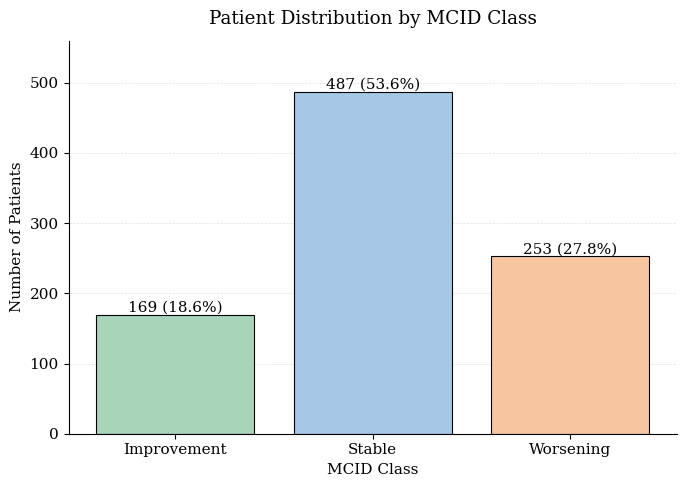

In [92]:
import matplotlib.pyplot as plt

# Conteo asegurando el orden 0-1-2-3
counts = data_V08['MCID_CLASS'].value_counts().reindex([0,1,2], fill_value=0)

# Etiquetas de cada stage
stage_labels = {
    0: 'Improvement',
    1: "Stable",
    2: "Worsening"
}

counts_df = counts.reset_index()
counts_df.columns = ['MCID_CLASS', 'Count']
counts_df['Stage_label'] = counts_df['MCID_CLASS'].map(stage_labels)

# Porcentajes
total = counts_df['Count'].sum()
counts_df['Pct'] = counts_df['Count'] / total * 100

# Colores pastel
color_map = {
    0: "#A8D5BA",  # verde pastel
    1: "#A7C7E7",  # azul pastel
    2: "#F7C59F",  # naranja pastel
}

colors = [color_map[i] for i in counts_df['MCID_CLASS']]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    counts_df['Stage_label'],
    counts_df['Count'],
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Texto encima de las barras
for bar, count, pct in zip(bars, counts_df['Count'], counts_df['Pct']):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{count} ({pct:.1f}%)",
        ha='center',
        va='bottom'
    )

ax.set_title("Patient Distribution by MCID Class", pad=12)
ax.set_xlabel("MCID Class")
ax.set_ylabel("Number of Patients")

# Estilo limpio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)

ax.set_ylim(0, counts_df['Count'].max()*1.15)

plt.tight_layout()
plt.show()

In [93]:
data_final = pd.merge(data_V08, data_stats, left_index=True, right_index=True)
print("data_final:", data_final.shape)
data_final.head()

data_final: (909, 937)


,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCID_CLASS,MCAALTTM_mean,MCACUBE_mean,MCACLCKC_mean,...,NP3PTRML_std,NP3KTRMR_std,NP3KTRML_std,NP3RTARU_std,NP3RTALU_std,NP3RTARL_std,NP3RTALL_std,NP3RTALJ_std,NP3RTCON_std,NHY_std
PATNO,,,,,,,,,,,,,,,,,,,,,
3003,0,0,0.0,1.0,16.0,59.7,1,1.000000,1.000000,1.0,...,0.577350,0.000000,0.57735,1.154701,0.000000,0.000000,0.0,0.0,0.577350,0.00000
3018,0,0,0.0,1.0,16.0,63.6,1,1.000000,0.666667,1.0,...,1.154701,1.154701,0.57735,0.577350,0.577350,0.577350,0.0,0.0,1.527525,0.00000
3020,0,0,0.0,1.0,15.0,77.0,2,0.666667,0.666667,1.0,...,0.000000,0.000000,0.00000,0.577350,1.154701,1.154701,0.0,0.0,1.154701,0.57735
3028,0,0,1.0,1.0,22.0,78.8,0,1.000000,1.000000,1.0,...,0.000000,0.000000,0.57735,0.000000,1.527525,0.000000,0.0,0.0,1.527525,0.00000
3051,0,0,1.0,1.0,18.0,74.7,1,1.000000,1.000000,1.0,...,0.000000,0.000000,0.00000,0.577350,0.000000,0.000000,0.0,0.0,0.577350,0.00000


In [94]:
data_final.drop(columns=["MCID_CLASS"]).to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv')
data_final["MCID_CLASS"].to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv')

In [95]:
train_data, test_data, train_target, test_target = train_test_split(
    data_final,
    data_final["MCID_CLASS"],
    test_size=0.2,
    random_state=42,
    stratify=data_final["MCID_CLASS"]
)

## Correlation Analysis

In [96]:
def correration_discard(train_data, threshold=0.9):
    list_vars_discard = []
    for type_corr in ['pearson', 'spearman']:
        # matriz de correlación
        corr_df = train_data.corr(method=type_corr)

        # máscara para solo la parte inferior de la matriz
        mask = np.tril(np.ones(corr_df.shape), k=-1).astype(bool)

        # convertir a formato largo
        corr_long = (
            corr_df.where(mask)
            .stack()
            .reset_index()
            .rename(columns={"level_0": "V1", "level_1": "V2", 0: "CORR"})
        )

        # correlación con el target
        target_corr = corr_df["MCID_CLASS"]

        corr_long["V1target"] = corr_long["V1"].map(target_corr)
        corr_long["V2target"] = corr_long["V2"].map(target_corr)
        corr_long["WORST_VAR"] = np.where(
            abs(corr_long["V1target"]) <= abs(corr_long["V2target"]),
            corr_long["V1"],
            corr_long["V2"]
        )

        discard_corr_long = corr_long.loc[corr_long["CORR"].abs() > threshold]
        discard_vars = set(discard_corr_long["WORST_VAR"])
        print("Variables a descartar por alta correlación de ", type_corr, " con threshold ", threshold, ":", discard_vars,'\n', len(discard_vars))
        list_vars_discard.extend(list(discard_vars))
        
    print("Total variables a descartar por alta correlación con threshold ", threshold, ":", len(set(list_vars_discard)))
    return list(set(list_vars_discard))

In [97]:
list_vars = correration_discard(train_data, threshold=0.90)
train_data_reduced = train_data.drop(columns=list_vars+["MCID_CLASS"])
test_data_reduced = test_data.drop(columns=list_vars+["MCID_CLASS"])

Variables a descartar por alta correlación de  pearson  con threshold  0.9 : {'ESS5_std', 'STAIAD4_max', 'NP3GAIT_std', 'MCAVFNUM_mean', 'NP3RIGLL_std', 'MCAABSTR_std', 'NP1SLPD_std', 'GDSHOPLS_mean', 'MCAABSTR_min', 'MCABDS_var', 'MCARHINO_std', 'NP1APAT_std', 'GDSWRTLS_var', 'MCAREC2_min', 'NP3RTCON_var', 'SCAU12_var', 'MCACLCKN_std', 'STAIAD17_var', 'NP3RIGN_std', 'NP2SWAL_max', 'GDSWRTLS_max', 'MCADATE_std', 'MCAVIGIL_min', 'GDSEMPTY_max', 'STAIAD24_mean', 'STAIAD13_max', 'NP3RIGRL_max', 'NP3BRADY_min', 'SCAU1_var', 'SCAU8_max', 'STAIAD24_std', 'GDSWRTLS_mean', 'NP3RISNG_mean', 'MCAVFNUM_std', 'DRMOBJFL_var', 'NP2RISE_max', 'SCAU15_max', 'MCALION_min', 'STAIAD23_mean', 'STAIAD19_var', 'NP3FTAPL_mean', 'MCAALTTM_mean', 'GDSHOPLS_max', 'STAIAD3_std', 'NP3RIGLL_max', 'STAIAD8_std', 'SLPDSTRB_var', 'MCADATE_min', 'MCACLCKC_std', 'STAIAD13_var', 'ESS6_max', 'SCAU10_var', 'SCAU4_max', 'STAIAD7_std', 'NP3TTAPL_var', 'GDSBETER_var', 'NP3FRZGT_mean', 'GDSBORED_std', 'MCAREC4_var', 'SCAU15_s

In [98]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data_reduced)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=train_data_reduced.columns, index=train_data_reduced.index)

X_test_scaled = scaler.transform(test_data_reduced)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=test_data_reduced.columns, index=test_data_reduced.index)

print("X_train_scaled shape:", X_train_scaled.shape)
print("y_train shape:", train_target.shape)

X_train_scaled shape: (727, 433)
y_train shape: (727,)


## Mutual Information

In [99]:
from sklearn.feature_selection import mutual_info_classif

X = X_train_scaled
y = train_target

mi = mutual_info_classif(X, y)
mi_series = pd.Series(mi, index=X_train_scaled.columns)
mi_series = mi_series.sort_values(ascending=False)

threshold = 0.025
selected_features = mi_series[mi_series > threshold]
list_selected_features = selected_features.index.tolist()
selected_features.head()

NP3BRADY_mean    0.098920
MSEADLG_mean     0.095065
NP3FTAPL_min     0.085895
NP3POSTR_max     0.083657
NP3PRSPL_mean    0.083637
dtype: float64

In [100]:
# duardar csv con las features seleccionadas
X_train_scaled[list_selected_features].to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/LATE_SELECTION/X_MCID_train.csv')
X_test_scaled[list_selected_features].to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/LATE_SELECTION/X_MCID_test.csv')
train_target.to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/LATE_SELECTION/y_MCID_train.csv')
test_target.to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/LATE_SELECTION/y_MCID_test.csv')

## Feature Selection Evaluation

In [101]:
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Convierte a numpy denso (evita objetos raros/pickle)
X_train = np.asarray(X_train_scaled[list_selected_features], dtype=np.float32)
X_test  = np.asarray(X_test_scaled[list_selected_features],  dtype=np.float32)

y_train = np.asarray(train_target)
y_test  = np.asarray(test_target)


# RF 
rf = RandomForestClassifier(
    n_estimators=600,
    random_state=42
)
oof_rf, test_rf = eval_model(rf, "RandomForest", X_train, y_train, X_test, y_test)

lr = LogisticRegression(
    solver="lbfgs",
    max_iter=5000,
    random_state=42
)
oof_lr, test_lr = eval_model(lr, "LogisticRegression", X_train, y_train, X_test, y_test)

# SVM con probas
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)
oof_svm, test_svm = eval_model(svm, "SVC_RBF", X_train, y_train, X_test, y_test)

xgb = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="mlogloss",
    )

oof_xgb, test_xgb = eval_model(xgb, "XGBoost", X_train, y_train, X_test, y_test)


RandomForest
Fold 1: AUC=0.7109
Fold 2: AUC=0.6820
Fold 3: AUC=0.6933
Fold 4: AUC=0.7536
Fold 5: AUC=0.7192
------
OOF Train AUC: 0.7086
Test CV  AUC: 0.7269

LogisticRegression
Fold 1: AUC=0.6387
Fold 2: AUC=0.5678
Fold 3: AUC=0.5954
Fold 4: AUC=0.6406
Fold 5: AUC=0.6187
------
OOF Train AUC: 0.6115
Test CV  AUC: 0.5995

SVC_RBF
Fold 1: AUC=0.6662
Fold 2: AUC=0.6734
Fold 3: AUC=0.6823
Fold 4: AUC=0.7095
Fold 5: AUC=0.7190
------
OOF Train AUC: 0.6862
Test CV  AUC: 0.7063

XGBoost
Fold 1: AUC=0.6757
Fold 2: AUC=0.6532
Fold 3: AUC=0.6731
Fold 4: AUC=0.6934
Fold 5: AUC=0.6732
------
OOF Train AUC: 0.6727
Test CV  AUC: 0.6742


# DELTA REDRESSION

In [102]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR

from xgboost import XGBRegressor

# =========================
# 1) Load + build target Delta
# =========================
current_dir = Path.cwd()
project_root = current_dir.parents[2]
path_data = project_root / 'DATA_PPMI/Results/MODEL_DATA/DATA_BL_V08.csv'
data = pd.read_csv(path_data, index_col=0)

updrs3_cols = ['NP3SPCH','NP3FACXP','NP3RIGN','NP3RIGRU','NP3RIGLU','NP3RIGRL','NP3RIGLL',
              'NP3FTAPR','NP3FTAPL','NP3HMOVR','NP3HMOVL','NP3PRSPR','NP3PRSPL','NP3TTAPR',
              'NP3TTAPL','NP3LGAGR','NP3LGAGL','NP3RISNG','NP3GAIT','NP3FRZGT','NP3PSTBL',
              'NP3POSTR','NP3BRADY','NP3PTRMR','NP3PTRML','NP3KTRMR','NP3KTRML','NP3RTARU',
              'NP3RTALU','NP3RTARL','NP3RTALL','NP3RTALJ','NP3RTCON']

V08_cols = ['ENRLLRRK2', 'ENRLGBA', 'COHORT_DEFINITION', 'SEX', 'RAWHITE', 'EDUCYRS', 'AGE_AT_VISIT']

# V08 totals
data_V08 = data[V08_cols + ['EVENT_ID'] + updrs3_cols].copy()
data_V08['UPDRS3_TOTAL_V08'] = data_V08[updrs3_cols].sum(axis=1)
data_V08.drop(columns=updrs3_cols, inplace=True)
data_V08 = data_V08.loc[data_V08["EVENT_ID"] == 'V08', :]

# V06 totals
data_V06 = data[V08_cols + ['EVENT_ID'] + updrs3_cols].copy()
data_V06['UPDRS3_TOTAL_V06'] = data_V06[updrs3_cols].sum(axis=1)
data_V06.drop(columns=updrs3_cols, inplace=True)
data_V06 = data_V06.loc[data_V06["EVENT_ID"] == 'V06', :]

# Merge to compute delta
df_target = data_V08.merge(
    data_V06[['UPDRS3_TOTAL_V06']],
    left_index=True, right_index=True,
    how='inner'
)
df_target['Delta_UPDRS3'] = df_target['UPDRS3_TOTAL_V08'] - df_target['UPDRS3_TOTAL_V06']

# Keep baseline-ish columns as features (optional) + target
df_target = df_target.drop(columns=["EVENT_ID", "COHORT_DEFINITION", "UPDRS3_TOTAL_V06", "UPDRS3_TOTAL_V08"])

In [103]:
# =========================
# 2) Build longitudinal feature stats (BL, V04, V06)
# =========================
other_cols = [col for col in data.columns if col not in V08_cols]
data_stats = data[other_cols].copy()
data_stats = data_stats.loc[data_stats["EVENT_ID"].isin(['BL', 'V04', 'V06']), :]
data_stats = data_stats.drop(columns=["EVENT_ID"])

df_grouped = data_stats.groupby(level="PATNO")
df_mean = df_grouped.mean().add_suffix("_mean")
df_min  = df_grouped.min().add_suffix("_min")
df_max  = df_grouped.max().add_suffix("_max")
df_var  = df_grouped.var().add_suffix("_var")
df_std  = df_grouped.std().add_suffix("_std")

data_stats_agg = pd.concat([df_mean, df_min, df_max, df_var, df_std], axis=1)

# Final dataset (features + target)
data_final = pd.merge(df_target, data_stats_agg, left_index=True, right_index=True)

print("data_final:", data_final.shape)

data_final: (909, 937)


In [104]:
data_final.drop(columns=["Delta_UPDRS3"]).to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_REG_full.csv')
data_final["Delta_UPDRS3"].to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_REG_full.csv')

In [105]:
# =========================
# 3) Train/test split (regression)
# =========================
# (sin stratify porque ya no es clasificación)
train_data, test_data = train_test_split(
    data_final,
    test_size=0.2,
    random_state=42
)

y_train = train_data["Delta_UPDRS3"].astype(float)
y_test  = test_data["Delta_UPDRS3"].astype(float)


In [106]:
# =========================
# 4) Correlation discard (against each other, keep best wrt target)
# =========================
def correlation_discard_regression(train_df, target_col="Delta_UPDRS3", threshold=0.9):
    df = train_df.copy()

    # Solo numéricas
    df_num = df.select_dtypes(include=[np.number]).copy()
    if target_col not in df_num.columns:
        raise ValueError(f"Target '{target_col}' must be numeric and present in df.")

    list_vars_discard = []

    for method in ['pearson', 'spearman']:
        corr_df = df_num.corr(method=method)

        # lower triangle mask
        mask = np.tril(np.ones(corr_df.shape), k=-1).astype(bool)

        corr_long = (
            corr_df.where(mask)
            .stack()
            .reset_index()
            .rename(columns={"level_0": "V1", "level_1": "V2", 0: "CORR"})
        )

        target_corr = corr_df[target_col]
        corr_long["V1target"] = corr_long["V1"].map(target_corr)
        corr_long["V2target"] = corr_long["V2"].map(target_corr)

        # discard the one with weaker |corr| to target
        corr_long["WORST_VAR"] = np.where(
            corr_long["V1target"].abs() <= corr_long["V2target"].abs(),
            corr_long["V1"], corr_long["V2"]
        )

        discard_corr_long = corr_long.loc[corr_long["CORR"].abs() > threshold]
        discard_vars = set(discard_corr_long["WORST_VAR"])

        print(f"[{method}] vars to discard (|corr|>{threshold}): {len(discard_vars)}")
        list_vars_discard.extend(list(discard_vars))

    list_vars_discard = sorted(set(list_vars_discard))
    print("Total unique vars to discard:", len(list_vars_discard))
    return list_vars_discard

list_vars = correlation_discard_regression(train_data, target_col="Delta_UPDRS3", threshold=0.90)

X_train_df = train_data.drop(columns=list_vars + ["Delta_UPDRS3"])
X_test_df  = test_data.drop(columns=list_vars + ["Delta_UPDRS3"])

# One-hot si hay categóricas (muy común: SEX, RAWHITE, etc.)
X_train_df = pd.get_dummies(X_train_df, drop_first=True)
X_test_df  = pd.get_dummies(X_test_df, drop_first=True)

# Alinear columnas entre train/test
X_train_df, X_test_df = X_train_df.align(X_test_df, join="left", axis=1, fill_value=0)

[pearson] vars to discard (|corr|>0.9): 312
[spearman] vars to discard (|corr|>0.9): 420
Total unique vars to discard: 509


In [107]:
# =========================
# 5) Scale
# =========================
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_df),
    columns=X_train_df.columns,
    index=X_train_df.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_df),
    columns=X_test_df.columns,
    index=X_test_df.index
)

print("X_train_scaled:", X_train_scaled.shape)

X_train_scaled: (727, 427)


In [108]:

# =========================
# 6) Mutual Information (regression)
# =========================
mi = mutual_info_regression(X_train_scaled, y_train, random_state=42)
mi_series = pd.Series(mi, index=X_train_scaled.columns).sort_values(ascending=False)

threshold_mi = 0.01  # ajusta según cuántas features quieras
selected = mi_series[mi_series > threshold_mi]
list_selected_features = selected.index.tolist()

print("Selected features by MI:", len(list_selected_features))
print(selected.head(15))

X_train = np.asarray(X_train_scaled[list_selected_features], dtype=np.float32)
X_test  = np.asarray(X_test_scaled[list_selected_features],  dtype=np.float32)


Selected features by MI: 177
NP3GAIT_mean     0.146203
NP3RIGN_mean     0.141362
NP3FTAPL_mean    0.133253
NP3RIGLU_max     0.127534
NP3FACXP_mean    0.117343
NP3TTAPL_min     0.102630
NP2TRMR_min      0.098386
NP3RIGRU_max     0.091937
NP3TTAPL_mean    0.087893
NP3SPCH_mean     0.087010
NP3RIGLL_max     0.085839
NP3PRSPR_min     0.082526
NP3RIGRL_mean    0.081248
NP3KTRML_max     0.079566
NP2TRMR_max      0.076821
dtype: float64


In [109]:
X_train_scaled[list_selected_features].to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/LATE_SELECTION/X_MCID_REG_train.csv')
X_test_scaled[list_selected_features].to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/LATE_SELECTION/X_MCID_REG_test.csv')
y_train.to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/LATE_SELECTION/y_MCID_REG_train.csv')
y_test.to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/LATE_SELECTION/y_MCID_REG_test.csv')

In [110]:

# =========================
# 7) Evaluate regressors (OOF Train + CV-Averaged Test)
# =========================

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
import numpy as np

def eval_regressor(model, name, X_train, y_train, X_test, y_test, n_splits=5):

    y_train = np.asarray(y_train).ravel()
    y_test  = np.asarray(y_test).ravel()

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    oof_pred = np.zeros(X_train.shape[0])
    test_pred = np.zeros(X_test.shape[0])

    print(f"\n{name}")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), start=1):

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)

        pred_val = m.predict(X_val)
        oof_pred[val_idx] = pred_val

        test_pred += m.predict(X_test) / n_splits

        # métricas del fold
        mae = mean_absolute_error(y_val, pred_val)
        rmse = mean_squared_error(y_val, pred_val) ** 0.5
        r2 = r2_score(y_val, pred_val)

        print(f"Fold {fold}: MAE={mae:.3f} | RMSE={rmse:.3f} | R2={r2:.3f}")


    def metrics(y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = mean_squared_error(y_true, y_pred) ** 0.5
        r2 = r2_score(y_true, y_pred)
        return mae, rmse, r2


    oof_mae, oof_rmse, oof_r2 = metrics(y_train, oof_pred)
    te_mae, te_rmse, te_r2 = metrics(y_test, test_pred)

    print("------")
    print(f"OOF Train: MAE={oof_mae:.3f} | RMSE={oof_rmse:.3f} | R2={oof_r2:.3f}")
    print(f"Test CV  : MAE={te_mae:.3f} | RMSE={te_rmse:.3f} | R2={te_r2:.3f}")

    return oof_pred, test_pred

rf = RandomForestRegressor(
    n_estimators=600,
    random_state=42,
    n_jobs=-1
)

ridge = Ridge(alpha=1.0, random_state=42)

svr = SVR(kernel="rbf", C=1.0, gamma="scale")

xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=800,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42
)

oof_rf, test_rf = eval_regressor(rf, "RandomForestRegressor", X_train, y_train, X_test, y_test)
oof_ridge, test_ridge = eval_regressor(ridge, "Ridge", X_train, y_train, X_test, y_test)
oof_svr, test_svr = eval_regressor(svr, "SVR_RBF", X_train, y_train, X_test, y_test)
oof_xgb, test_xgb = eval_regressor(xgb, "XGBRegressor", X_train, y_train, X_test, y_test)


RandomForestRegressor
Fold 1: MAE=4.108 | RMSE=5.778 | R2=0.055
Fold 2: MAE=4.442 | RMSE=5.967 | R2=0.121
Fold 3: MAE=4.705 | RMSE=6.934 | R2=0.037
Fold 4: MAE=4.707 | RMSE=6.659 | R2=0.030
Fold 5: MAE=4.681 | RMSE=6.619 | R2=-0.031
------
OOF Train: MAE=4.528 | RMSE=6.405 | R2=0.047
Test CV  : MAE=4.724 | RMSE=7.241 | R2=-0.051

Ridge
Fold 1: MAE=4.927 | RMSE=6.786 | R2=-0.304
Fold 2: MAE=5.510 | RMSE=7.528 | R2=-0.400
Fold 3: MAE=5.469 | RMSE=7.761 | R2=-0.206
Fold 4: MAE=5.976 | RMSE=8.113 | R2=-0.440
Fold 5: MAE=5.084 | RMSE=7.210 | R2=-0.223
------
OOF Train: MAE=5.393 | RMSE=7.492 | R2=-0.304
Test CV  : MAE=5.875 | RMSE=8.592 | R2=-0.479

SVR_RBF
Fold 1: MAE=4.122 | RMSE=5.776 | R2=0.055
Fold 2: MAE=4.468 | RMSE=6.258 | R2=0.033
Fold 3: MAE=4.684 | RMSE=7.018 | R2=0.013
Fold 4: MAE=4.652 | RMSE=6.770 | R2=-0.003
Fold 5: MAE=4.593 | RMSE=6.588 | R2=-0.021
------
OOF Train: MAE=4.503 | RMSE=6.495 | R2=0.020
Test CV  : MAE=4.644 | RMSE=7.130 | R2=-0.019

XGBRegressor
Fold 1: MAE=4.

# UPDRS 3 Regression

In [111]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR

from xgboost import XGBRegressor


# ----------------------------
# 0) Load data
# ----------------------------
current_dir = Path.cwd()
project_root = current_dir.parents[2]
path_data = project_root / 'DATA_PPMI/Results/MODEL_DATA/DATA_BL_V08.csv'
data = pd.read_csv(path_data, index_col=0)

In [112]:
# ----------------------------
# 1) Build target at V08: UPDRS3_TOTAL_V08
# ----------------------------
updrs3_cols = [
    'NP3SPCH','NP3FACXP','NP3RIGN','NP3RIGRU','NP3RIGLU','NP3RIGRL','NP3RIGLL',
    'NP3FTAPR','NP3FTAPL','NP3HMOVR','NP3HMOVL','NP3PRSPR','NP3PRSPL','NP3TTAPR',
    'NP3TTAPL','NP3LGAGR','NP3LGAGL','NP3RISNG','NP3GAIT','NP3FRZGT','NP3PSTBL',
    'NP3POSTR','NP3BRADY','NP3PTRMR','NP3PTRML','NP3KTRMR','NP3KTRML','NP3RTARU',
    'NP3RTALU','NP3RTARL','NP3RTALL','NP3RTALJ','NP3RTCON'
]

V08_cols = ['ENRLLRRK2', 'ENRLGBA', 'COHORT_DEFINITION', 'SEX', 'RAWHITE', 'EDUCYRS', 'AGE_AT_VISIT']

# Keep V08 baseline-ish covariates as features + compute UPDRS3 total as target
data_V08 = data[V08_cols + ['EVENT_ID'] + updrs3_cols].copy()
data_V08['UPDRS3_TOTAL_V08'] = data_V08[updrs3_cols].sum(axis=1)
data_V08.drop(columns=updrs3_cols, inplace=True)
data_V08 = data_V08.loc[data_V08["EVENT_ID"] == 'V08', :].copy()

# Drop columns you don't want as features
# (COHORT_DEFINITION often treated as label-ish; drop if you want)
data_V08.drop(columns=["EVENT_ID", "COHORT_DEFINITION"], inplace=True)

print("data_V08:", data_V08.shape)
print(data_V08[['UPDRS3_TOTAL_V08']].describe())

data_V08: (909, 7)
       UPDRS3_TOTAL_V08
count        909.000000
mean          16.250825
std           15.753148
min            0.000000
25%            2.000000
50%           11.000000
75%           27.000000
max           80.000000


In [113]:
# ----------------------------
# 2) Longitudinal aggregated features from BL/V04/V06 (mean/min/max/var/std)
# ----------------------------
other_cols = [col for col in data.columns if col not in V08_cols]
data_stats = data[other_cols].copy()
data_stats = data_stats.loc[data_stats["EVENT_ID"].isin(['BL', 'V04', 'V06']), :].copy()
data_stats.drop(columns=["EVENT_ID"], inplace=True)

df_grouped = data_stats.groupby(level="PATNO")
df_mean = df_grouped.mean().add_suffix("_mean")
df_min  = df_grouped.min().add_suffix("_min")
df_max  = df_grouped.max().add_suffix("_max")
df_var  = df_grouped.var().add_suffix("_var")
df_std  = df_grouped.std().add_suffix("_std")

data_stats_agg = pd.concat([df_mean, df_min, df_max, df_var, df_std], axis=1)

# Final dataset
data_final = pd.merge(data_V08, data_stats_agg, left_index=True, right_index=True, how="inner")
print("data_final:", data_final.shape)


data_final: (909, 937)


In [ ]:
data_final.drop(columns=["UPDRS3_TOTAL_V08"]).to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_UPDRS3_REG_full.csv')
data_final["UPDRS3_TOTAL_V08"].to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_UPDRS3_REG_full.csv')

In [115]:
# ----------------------------
# 3) Train/Test split
# ----------------------------
train_df, test_df = train_test_split(
    data_final,
    test_size=0.2,
    random_state=42
)

y_train = train_df["UPDRS3_TOTAL_V08"].astype(float)
y_test  = test_df["UPDRS3_TOTAL_V08"].astype(float)

In [116]:
# ----------------------------
# 4) Correlation-based discard (Pearson + Spearman)
#     Remove one of each highly-correlated pair: the one less correlated to target.
# ----------------------------
def correlation_discard_regression(df, target_col="UPDRS3_TOTAL_V08", threshold=0.90):
    df = df.copy()

    # keep numeric only for correlation
    df_num = df.select_dtypes(include=[np.number]).copy()
    if target_col not in df_num.columns:
        raise ValueError(f"Target '{target_col}' must be numeric and present in df_num.")

    discards = []

    for method in ["pearson", "spearman"]:
        corr = df_num.corr(method=method)

        # lower triangle mask
        mask = np.tril(np.ones(corr.shape), k=-1).astype(bool)

        corr_long = (
            corr.where(mask)
            .stack()
            .reset_index()
            .rename(columns={"level_0": "V1", "level_1": "V2", 0: "CORR"})
        )

        # corr with target
        target_corr = corr[target_col]
        corr_long["V1target"] = corr_long["V1"].map(target_corr)
        corr_long["V2target"] = corr_long["V2"].map(target_corr)

        # discard the one with smaller |corr| to target
        corr_long["WORST_VAR"] = np.where(
            corr_long["V1target"].abs() <= corr_long["V2target"].abs(),
            corr_long["V1"],
            corr_long["V2"]
        )

        high = corr_long.loc[corr_long["CORR"].abs() > threshold].copy()
        discard_vars = set(high["WORST_VAR"].tolist())

        # never discard target itself
        discard_vars.discard(target_col)

        print(f"[{method}] discard |corr|>{threshold}: {len(discard_vars)}")
        discards.extend(list(discard_vars))

    discards = sorted(set(discards))
    print("Total unique discarded:", len(discards))
    return discards

list_discard = correlation_discard_regression(train_df, target_col="UPDRS3_TOTAL_V08", threshold=0.90)


[pearson] discard |corr|>0.9: 320
[spearman] discard |corr|>0.9: 422
Total unique discarded: 511


In [117]:
# ----------------------------
# 5) Build X (with categoricals handled) + scale
# ----------------------------
X_train_df = train_df.drop(columns=list_discard + ["UPDRS3_TOTAL_V08"])
X_test_df  = test_df.drop(columns=list_discard + ["UPDRS3_TOTAL_V08"])

# one-hot encode categoricals (SEX, RAWHITE, etc)
X_train_df = pd.get_dummies(X_train_df, drop_first=True)
X_test_df  = pd.get_dummies(X_test_df, drop_first=True)

# align columns
X_train_df, X_test_df = X_train_df.align(X_test_df, join="left", axis=1, fill_value=0)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_df),
    columns=X_train_df.columns,
    index=X_train_df.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_df),
    columns=X_test_df.columns,
    index=X_test_df.index
)

print("X_train_scaled:", X_train_scaled.shape)

X_train_scaled: (727, 425)


In [118]:
# ----------------------------
# 6) Mutual Information (regression) feature selection
# ----------------------------
mi = mutual_info_regression(X_train_scaled, y_train, random_state=42)
mi_series = pd.Series(mi, index=X_train_scaled.columns).sort_values(ascending=False)

# Option A: threshold
mi_threshold = 0.01
selected_by_threshold = mi_series[mi_series > mi_threshold].index.tolist()

print("Selected features:", len(selected_by_threshold))
print(mi_series.head(20))

X_train = np.asarray(X_train_scaled[selected_by_threshold], dtype=np.float32)
X_test  = np.asarray(X_test_scaled[selected_by_threshold], dtype=np.float32)

Selected features: 234
NP3BRADY_mean    0.578031
NHY_mean         0.569084
NP3FACXP_mean    0.479235
NP3FTAPL_mean    0.414221
MSEADLG_mean     0.380837
NP3RIGRU_mean    0.348698
NP3HMOVL_mean    0.343589
NP3PRSPR_mean    0.335415
NP2TRMR_mean     0.331411
NP3TTAPR_mean    0.328611
NP3SPCH_mean     0.322319
NP3FTAPR_mean    0.319226
NP3RIGN_mean     0.312903
NP3TTAPL_mean    0.310067
NP3GAIT_mean     0.308705
NP3FACXP_min     0.303025
NP3LGAGR_mean    0.285247
NP3RTCON_std     0.280565
NP3HMOVR_mean    0.276899
NP3LGAGL_mean    0.262997
dtype: float64


In [119]:
X_train_scaled[selected_by_threshold].to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/LATE_SELECTION/X_UPDRS3_REG_train.csv')
X_test_scaled[selected_by_threshold].to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/LATE_SELECTION/X_UPDRS3_REG_test.csv')
y_train.to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/LATE_SELECTION/y_UPDRS3_REG_train.csv')
y_test.to_csv(project_root/'SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/LATE_SELECTION/y_UPDRS3_REG_test.csv')

In [120]:

# =========================
# 7) Evaluate regressors (OOF Train + CV-Averaged Test)
# =========================

rf = RandomForestRegressor(
    n_estimators=600,
    random_state=42,
    n_jobs=-1
)

ridge = Ridge(alpha=1.0, random_state=42)

svr = SVR(kernel="rbf", C=1.0, gamma="scale")

xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=800,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42
)

oof_rf, test_rf = eval_regressor(rf, "RandomForestRegressor", X_train, y_train, X_test, y_test)
oof_ridge, test_ridge = eval_regressor(ridge, "Ridge", X_train, y_train, X_test, y_test)
oof_svr, test_svr = eval_regressor(svr, "SVR_RBF", X_train, y_train, X_test, y_test)
oof_xgb, test_xgb = eval_regressor(xgb, "XGBRegressor", X_train, y_train, X_test, y_test)


RandomForestRegressor
Fold 1: MAE=6.193 | RMSE=8.272 | R2=0.735
Fold 2: MAE=5.497 | RMSE=7.350 | R2=0.802
Fold 3: MAE=4.916 | RMSE=6.833 | R2=0.815
Fold 4: MAE=4.978 | RMSE=7.238 | R2=0.791
Fold 5: MAE=5.312 | RMSE=7.363 | R2=0.749
------
OOF Train: MAE=5.381 | RMSE=7.427 | R2=0.781
Test CV  : MAE=4.663 | RMSE=7.301 | R2=0.769

Ridge
Fold 1: MAE=7.294 | RMSE=10.194 | R2=0.598
Fold 2: MAE=6.745 | RMSE=9.046 | R2=0.700
Fold 3: MAE=5.891 | RMSE=8.806 | R2=0.692
Fold 4: MAE=6.432 | RMSE=8.586 | R2=0.706
Fold 5: MAE=6.817 | RMSE=8.673 | R2=0.651
------
OOF Train: MAE=6.637 | RMSE=9.081 | R2=0.672
Test CV  : MAE=6.170 | RMSE=9.048 | R2=0.645

SVR_RBF
Fold 1: MAE=7.394 | RMSE=10.368 | R2=0.584
Fold 2: MAE=7.795 | RMSE=10.652 | R2=0.584
Fold 3: MAE=6.664 | RMSE=9.491 | R2=0.643
Fold 4: MAE=7.375 | RMSE=9.847 | R2=0.613
Fold 5: MAE=6.425 | RMSE=8.362 | R2=0.676
------
OOF Train: MAE=7.132 | RMSE=9.779 | R2=0.620
Test CV  : MAE=6.229 | RMSE=9.198 | R2=0.633

XGBRegressor
Fold 1: MAE=5.886 | RMS